pingouin available — ICC will be computed.
Libraries loaded successfully.
Data and pipelines loaded.
Male   batch CFs  : 200 rows
Female batch CFs  : 200 rows
Male   robustness : 10 cases
Female robustness : 10 cases
Models loaded for robustness analysis.
  Male   : ['XGBoost', 'CatBoost', 'LightGBM']
  Female : ['XGBoost', 'RandomForest', 'LightGBM']
Running robustness — Male (10 cases × 3 models)...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.02it/s]


Running robustness — Female (10 cases × 3 models)...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.44it/s]


Done.

=== ICC — Male ===
  ICC failed: 'CI95%'

=== ICC — Female ===
  ICC failed: 'CI95%'
=== Feature Consistency Scores ===
  Male   : 0.604 ± 0.165  [0.361 – 0.778]
  Female : 0.442 ± 0.247  [0.233 – 1.000]

=== Table 14: Robustness Analysis Results ===
                          Metric                          Male                            Female
                 Analysis models XGBoost / CatBoost / LightGBM XGBoost / RandomForest / LightGBM
                  Cases analysed                            10                                10
       Overall consistency score                 0.604 ± 0.165                     0.442 ± 0.247
    ICC2 (predicted probability)                          None                              None
                     ICC2 95% CI                          None                              None
Predicted prob consistency range                 0.097 – 0.347                     0.028 – 0.480
       Feature consistency range                 0.361 – 0.778 

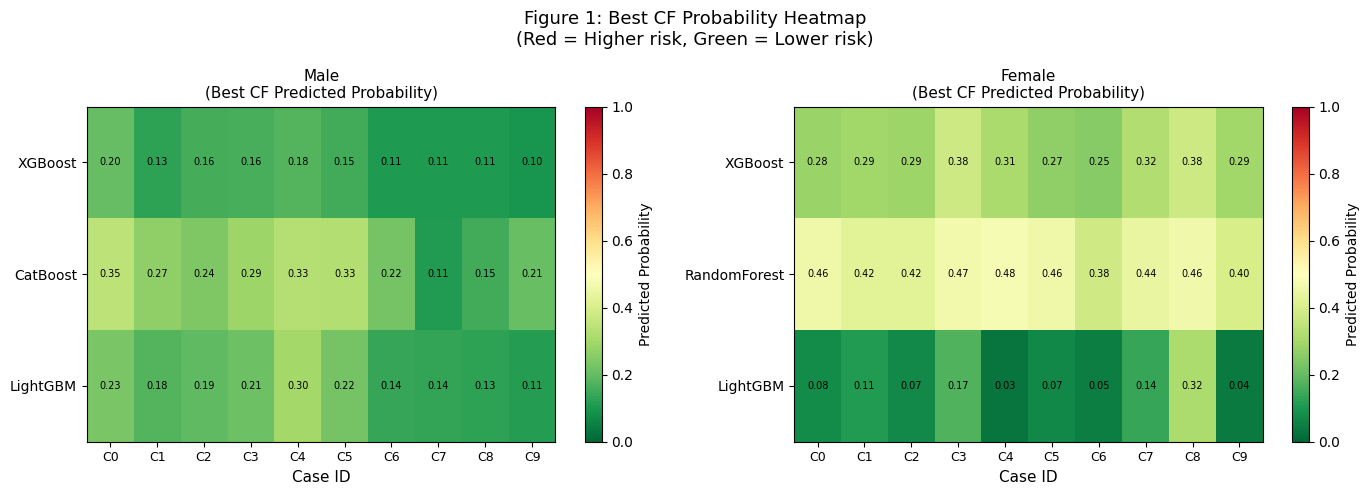

Saved: outputs/robustness/fig1_prob_heatmap.png


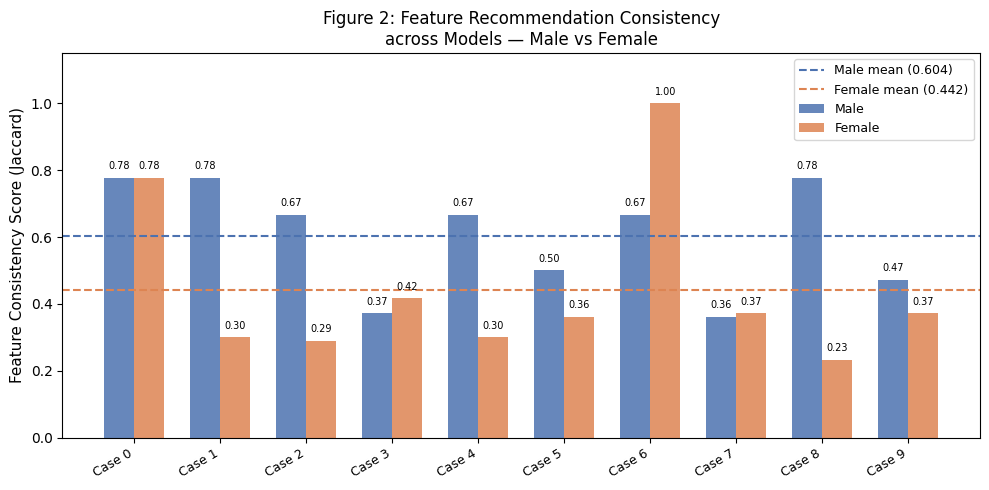

Saved: outputs/robustness/fig2_feature_consistency.png


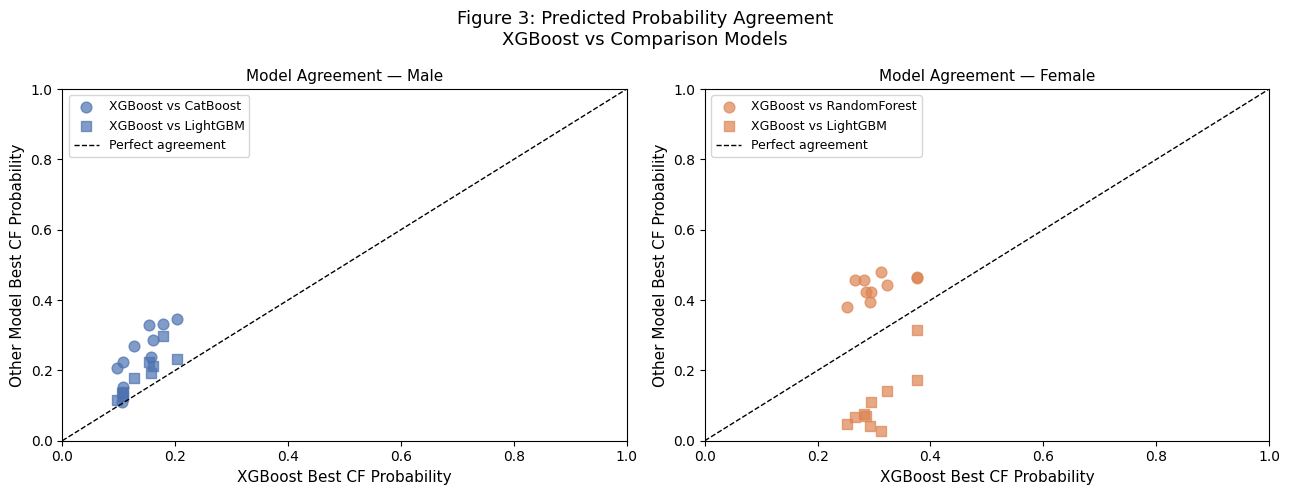

Saved: outputs/robustness/fig3_model_agreement.png

t-test (Male vs Female consistency): t=1.724, p=0.1018 (ns)


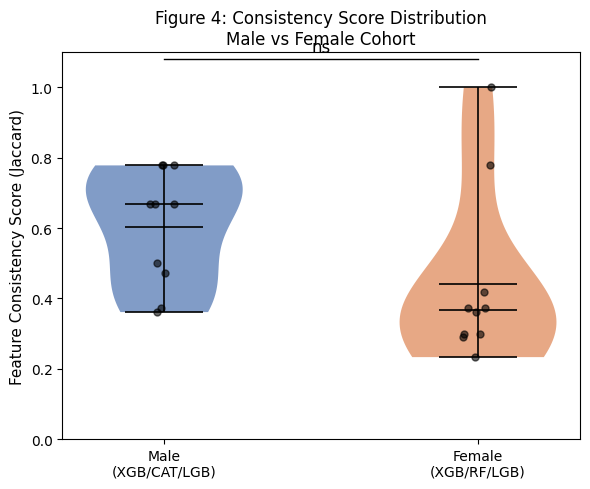

Saved: outputs/robustness/fig4_consistency_violin.png
=== Per-Case Recommended Features — Male ===
 Case    Model  Top1       Top2       Top3  Best_CF_Prob
    0  XGBoost HE_wc        edu          —        0.2030
    1  XGBoost HE_wc      BO1_1        edu        0.1271
    2  XGBoost HE_wc      BO1_1          —        0.1564
    3  XGBoost HE_wc      BO1_1     BE3_91        0.1613
    4  XGBoost HE_wc      BO1_1        edu        0.1788
    5  XGBoost HE_wc      BO1_1     BE3_91        0.1543
    6  XGBoost HE_wc      BO1_1     BE3_91        0.1071
    7  XGBoost HE_wc      HE_wt          —        0.1060
    8  XGBoost HE_wc pa_aerobic        BP1        0.1076
    9  XGBoost HE_wc      BO1_1 pa_aerobic        0.0971
    0 CatBoost HE_wc        BP1        edu        0.3473
    1 CatBoost HE_wc        edu          —        0.2684
    2 CatBoost HE_wc          —          —        0.2394
    3 CatBoost HE_wc        BP1        edu        0.2853
    4 CatBoost HE_wc        BP1        edu    

In [1]:
# ============================================================
# 09_robustness_analysis.ipynb
# Integrated Robustness Analysis — Male & Female
#
# Paper: A Methodology for Interpretable Health Risk Management:
#        Integrating Counterfactual Explanations and
#        On-Premise Medical LLMs in the Insurance Industry
#
# Contents:
#   1. Load robustness results from notebooks 07 & 08
#   2. Predicted probability consistency (ICC)
#   3. Recommended feature consistency (Jaccard-based)
#   4. Male vs Female robustness comparison
#   5. Per-case robustness deep-dive
#   6. Paper-ready tables & figures export
#      (corresponds to Table 14 in paper)
# ============================================================


# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import joblib, json, os
from scipy import stats
from sklearn.model_selection import train_test_split

try:
    from pingouin import intraclass_corr
    PINGOUIN_AVAILABLE = True
    print("pingouin available — ICC will be computed.")
except ImportError:
    PINGOUIN_AVAILABLE = False
    print("[Warning] pingouin not installed → ICC skipped.")
    print("  Install: pip install pingouin")

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
print("Libraries loaded successfully.")


# ─────────────────────────────────────────────
# Cell 2 | Load Data & Pipelines
# ─────────────────────────────────────────────
df_male   = pd.read_csv('outputs/df_male.csv')
df_female = pd.read_csv('outputs/df_female.csv')

df_nd_male   = pd.read_csv('outputs/df_male_nd_highrisk.csv')
df_nd_female = pd.read_csv('outputs/df_female_nd_highrisk.csv')

pipeline_male   = joblib.load('outputs/models_male/final_pipeline_male.pkl')
pipeline_female = joblib.load('outputs/models_female/final_pipeline_female.pkl')

feature_col = pipeline_male['feature_cols']
cat_col     = pipeline_male['cat_col']
num_col     = pipeline_male['num_col']
target_col  = pipeline_male['target_col']
thresh_m    = pipeline_male['threshold']
thresh_f    = pipeline_female['threshold']
prep_male   = pipeline_male['preprocessor']
prep_female = pipeline_female['preprocessor']

os.makedirs('outputs/robustness', exist_ok=True)
print("Data and pipelines loaded.")


# ─────────────────────────────────────────────
# Cell 3 | Load Batch CF Results
# ─────────────────────────────────────────────
df_batch_m = pd.read_csv('outputs/dice_male/batch_cf_male.csv')
df_batch_f = pd.read_csv('outputs/dice_female/batch_cf_female.csv')

df_cons_m  = pd.read_csv('outputs/dice_male/robustness_consistency.csv')
df_cons_f  = pd.read_csv('outputs/dice_female/robustness_consistency.csv')

print(f"Male   batch CFs  : {len(df_batch_m):,} rows")
print(f"Female batch CFs  : {len(df_batch_f):,} rows")
print(f"Male   robustness : {len(df_cons_m)} cases")
print(f"Female robustness : {len(df_cons_f)} cases")


# ─────────────────────────────────────────────
# Cell 4 | Rebuild Robustness Predictions
#          (Re-run 10 cases × 3 models per gender)
# ─────────────────────────────────────────────
import dice_ml
from dice_ml import Dice
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

class ModelWrapper:
    def __init__(self, model, preprocessor, threshold):
        self.model        = model
        self.preprocessor = preprocessor
        self.threshold    = threshold
    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = self.preprocessor.transform(X)
        return self.model.predict_proba(X)
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)

# ── Male models ──────────────────────────────
model_xgb_m = pipeline_male['model']
model_cat_m = joblib.load('outputs/models_male/cat_male.pkl')
model_lgb_m = joblib.load('outputs/models_male/lgb_male.pkl')

robust_models_m = {
    'XGBoost' : (model_xgb_m, prep_male,   thresh_m),
    'CatBoost': (model_cat_m, prep_male,   thresh_m),
    'LightGBM': (model_lgb_m, prep_male,   thresh_m),
}

# ── Female models ────────────────────────────
model_xgb_f = pipeline_female['model']
model_rf_f  = joblib.load('outputs/models_female/rf_female.pkl')
model_lgb_f = joblib.load('outputs/models_female/lgb_female.pkl')

robust_models_f = {
    'XGBoost'     : (model_xgb_f, prep_female, thresh_f),
    'RandomForest': (model_rf_f,  prep_female, thresh_f),
    'LightGBM'    : (model_lgb_f, prep_female, thresh_f),
}

print("Models loaded for robustness analysis.")
print(f"  Male   : {list(robust_models_m.keys())}")
print(f"  Female : {list(robust_models_f.keys())}")


# ─────────────────────────────────────────────
# Cell 5 | Robustness Helper Functions
# ─────────────────────────────────────────────
def build_dice_explainer(df_train, target, num_feats,
                         model, prep, thresh, method='random'):
    """Build a DiCE explainer for a given model."""
    df_d   = df_train[feature_col + [target]].copy()
    df_d[target] = df_d[target].astype(int)
    d_ = dice_ml.Data(
        dataframe           = df_d,
        continuous_features = num_feats,
        outcome_name        = target,
    )
    w  = ModelWrapper(model, prep, thresh)
    m_ = dice_ml.Model(model=w, backend='sklearn',
                        model_type='classifier')
    return Dice(d_, m_, method=method), w


def run_robustness(cases_df, robust_models_dict, df_train,
                   permitted_range, features_to_vary,
                   n_cf=4, random_seed=42):
    """
    Run DiCE for each case × each model.
    Returns dict: {model_name: [{'case_id','best_cf','cf_probs'},...]}
    """
    results = {name: [] for name in robust_models_dict}

    for name, (mdl, prep, thr) in robust_models_dict.items():
        exp_, wrap_ = build_dice_explainer(
            df_train, target_col, num_col, mdl, prep, thr
        )
        for idx in range(len(cases_df)):
            query = cases_df.iloc[[idx]][feature_col]
            try:
                cf_r = exp_.generate_counterfactuals(
                    query_instances  = query,
                    total_CFs        = n_cf,
                    desired_class    = 0,
                    features_to_vary = features_to_vary,
                    permitted_range  = permitted_range,
                    random_seed      = random_seed,
                    verbose          = False,
                )
                cf_df_ = cf_r.cf_examples_list[0].final_cfs_df
                probs_ = [
                    float(mdl.predict_proba(
                        prep.transform(cf_df_.iloc[[i]][feature_col])
                    )[:, 1][0])
                    for i in range(len(cf_df_))
                ]
                results[name].append({
                    'case_id' : idx,
                    'best_cf' : min(probs_),
                    'cf_probs': probs_,
                    'cf_df'   : cf_df_,
                })
            except Exception as e:
                print(f"  [Warning] {name} case {idx}: {e}")
                results[name].append({
                    'case_id': idx, 'best_cf': None,
                    'cf_probs': [None]*4, 'cf_df': None,
                })
    return results


def compute_feature_consistency(cases_df, results_dict, feature_col,
                                 num_col, top_k=3):
    """
    Compute Jaccard-based feature consistency across models per case.
    """
    rows = []
    for idx in range(len(cases_df)):
        top_feats = {}
        for name, results in results_dict.items():
            r = results[idx]
            if r['cf_df'] is None:
                continue
            orig_row = cases_df.iloc[idx]
            changes  = {}
            for col in feature_col:
                cf_vals = r['cf_df'][col].values
                orig_v  = orig_row[col]
                delta   = (np.mean(np.abs(cf_vals - orig_v))
                           if col in num_col
                           else float(np.mean(cf_vals != orig_v)))
                if delta > 0.01:
                    changes[col] = delta
            if changes:
                top_feats[name] = set(
                    sorted(changes, key=changes.get,
                           reverse=True)[:top_k]
                )
        if len(top_feats) >= 2:
            names    = list(top_feats.keys())
            overlaps = []
            for i in range(len(names)):
                for j in range(i+1, len(names)):
                    a, b = top_feats[names[i]], top_feats[names[j]]
                    o    = len(a & b) / len(a | b) if (a | b) else 0
                    overlaps.append(o)
            rows.append({
                'case_id'          : idx,
                'consistency_score': round(np.mean(overlaps), 3),
            })
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────
# Cell 6 | Run Robustness — Male
# ─────────────────────────────────────────────
with open('outputs/highrisk_cutoff_meta.json') as f:
    cutoff_meta = json.load(f)

df_nd_male_sorted = df_nd_male.sort_values(
    'pred_prob', ascending=False
).reset_index(drop=True)
df_nd_female_sorted = df_nd_female.sort_values(
    'pred_prob', ascending=False
).reset_index(drop=True)

robust_cases_m = df_nd_male_sorted.iloc[:10][feature_col].reset_index(drop=True)
robust_cases_f = df_nd_female_sorted.iloc[:10][feature_col].reset_index(drop=True)

# Permitted ranges
def permitted_range_male(df):
    return {
        'HE_BMI' : [max(18.5, round(df['HE_BMI'].min(),1)), round(df['HE_BMI'].max(),1)],
        'HE_wc'  : [max(60.0, round(df['HE_wc'].min(),1)),  round(df['HE_wc'].max(),1)],
        'HE_wt'  : [max(40.0, round(df['HE_wt'].min(),1)),  round(df['HE_wt'].max(),1)],
        'N_SUGAR': [0.0,   100.0],
        'N_CHO'  : [100.0, 400.0],
        'N_EN'   : [1200.0,3500.0],
        'age'    : [float(df['age'].min()), float(df['age'].max())],
    }

def permitted_range_female(df):
    return {
        'HE_BMI' : [max(17.5, round(df['HE_BMI'].min(),1)), round(df['HE_BMI'].max(),1)],
        'HE_wc'  : [max(55.0, round(df['HE_wc'].min(),1)),  round(df['HE_wc'].max(),1)],
        'HE_wt'  : [max(35.0, round(df['HE_wt'].min(),1)),  round(df['HE_wt'].max(),1)],
        'N_SUGAR': [0.0,   100.0],
        'N_CHO'  : [100.0, 400.0],
        'N_EN'   : [1200.0,2800.0],
        'age'    : [float(df['age'].min()), float(df['age'].max())],
    }

pr_m = permitted_range_male(df_male)
pr_f = permitted_range_female(df_female)

ftv_m = [c for c in feature_col if c != 'age']
ftv_f = [c for c in feature_col if c != 'age']

print("Running robustness — Male (10 cases × 3 models)...")
results_m = run_robustness(
    robust_cases_m, robust_models_m, df_male, pr_m, ftv_m
)
print("Running robustness — Female (10 cases × 3 models)...")
results_f = run_robustness(
    robust_cases_f, robust_models_f, df_female, pr_f, ftv_f
)
print("Done.")


# ─────────────────────────────────────────────
# Cell 7 | ICC Computation — Male & Female
# ─────────────────────────────────────────────
def build_icc_df(results_dict):
    rows = []
    for name, res_list in results_dict.items():
        for r in res_list:
            if r['best_cf'] is not None:
                rows.append({
                    'case_id': r['case_id'],
                    'rater'  : name,
                    'score'  : r['best_cf'],
                })
    return pd.DataFrame(rows)

df_icc_m = build_icc_df(results_m)
df_icc_f = build_icc_df(results_f)

icc_summary = {}

for label, df_icc in [('Male', df_icc_m), ('Female', df_icc_f)]:
    print(f"\n=== ICC — {label} ===")
    if PINGOUIN_AVAILABLE and len(df_icc) > 0:
        try:
            icc_res = intraclass_corr(
                data    = df_icc,
                targets = 'case_id',
                raters  = 'rater',
                ratings = 'score',
            )
            row = icc_res.set_index('Type').loc['ICC2']
            icc_val = row['ICC']
            icc_ci  = row['CI95%']
            icc_p   = row['pval']
            icc_summary[label] = {
                'ICC2'  : round(float(icc_val), 3),
                'CI95%' : icc_ci,
                'pval'  : float(icc_p),
            }
            print(icc_res[['Type','ICC','CI95%','pval']].to_string(index=False))
        except Exception as e:
            print(f"  ICC failed: {e}")
            icc_summary[label] = {'ICC2': None, 'CI95%': None, 'pval': None}
    else:
        pivot = df_icc.pivot(index='case_id', columns='rater', values='score')
        corr  = pivot.corr()
        print("  Pearson correlation (fallback):")
        print(corr.round(3))
        icc_summary[label] = {'ICC2': None, 'CI95%': 'N/A', 'pval': None}


# ─────────────────────────────────────────────
# Cell 8 | Feature Consistency — Male & Female
# ─────────────────────────────────────────────
df_feat_cons_m = compute_feature_consistency(
    robust_cases_m, results_m, feature_col, num_col
)
df_feat_cons_f = compute_feature_consistency(
    robust_cases_f, results_f, feature_col, num_col
)

mean_cons_m = df_feat_cons_m['consistency_score'].mean()
std_cons_m  = df_feat_cons_m['consistency_score'].std()
mean_cons_f = df_feat_cons_f['consistency_score'].mean()
std_cons_f  = df_feat_cons_f['consistency_score'].std()

print("=== Feature Consistency Scores ===")
print(f"  Male   : {mean_cons_m:.3f} ± {std_cons_m:.3f}  "
      f"[{df_feat_cons_m['consistency_score'].min():.3f} – "
      f"{df_feat_cons_m['consistency_score'].max():.3f}]")
print(f"  Female : {mean_cons_f:.3f} ± {std_cons_f:.3f}  "
      f"[{df_feat_cons_f['consistency_score'].min():.3f} – "
      f"{df_feat_cons_f['consistency_score'].max():.3f}]")


# ─────────────────────────────────────────────
# Cell 9 | Table 1 — Integrated Robustness
#          Summary (Paper Table 14)
# ─────────────────────────────────────────────
icc_m_val = icc_summary['Male'].get('ICC2', 'N/A')
icc_f_val = icc_summary['Female'].get('ICC2', 'N/A')
icc_m_ci  = icc_summary['Male'].get('CI95%', 'N/A')
icc_f_ci  = icc_summary['Female'].get('CI95%', 'N/A')

# Prob consistency range from icc df
prob_range_m = (
    f"{df_icc_m['score'].min():.3f} – {df_icc_m['score'].max():.3f}"
    if len(df_icc_m) > 0 else 'N/A'
)
prob_range_f = (
    f"{df_icc_f['score'].min():.3f} – {df_icc_f['score'].max():.3f}"
    if len(df_icc_f) > 0 else 'N/A'
)

df_table14 = pd.DataFrame([
    {
        'Metric'                        : 'Analysis models',
        'Male'                          : 'XGBoost / CatBoost / LightGBM',
        'Female'                        : 'XGBoost / RandomForest / LightGBM',
    },
    {
        'Metric'                        : 'Cases analysed',
        'Male'                          : '10',
        'Female'                        : '10',
    },
    {
        'Metric'                        : 'Overall consistency score',
        'Male'                          : f"{mean_cons_m:.3f} ± {std_cons_m:.3f}",
        'Female'                        : f"{mean_cons_f:.3f} ± {std_cons_f:.3f}",
    },
    {
        'Metric'                        : 'ICC2 (predicted probability)',
        'Male'                          : str(icc_m_val),
        'Female'                        : str(icc_f_val),
    },
    {
        'Metric'                        : 'ICC2 95% CI',
        'Male'                          : str(icc_m_ci),
        'Female'                        : str(icc_f_ci),
    },
    {
        'Metric'                        : 'Predicted prob consistency range',
        'Male'                          : prob_range_m,
        'Female'                        : prob_range_f,
    },
    {
        'Metric'                        : 'Feature consistency range',
        'Male'                          : f"{df_feat_cons_m['consistency_score'].min():.3f} – "
                                          f"{df_feat_cons_m['consistency_score'].max():.3f}",
        'Female'                        : f"{df_feat_cons_f['consistency_score'].min():.3f} – "
                                          f"{df_feat_cons_f['consistency_score'].max():.3f}",
    },
])

print("\n=== Table 14: Robustness Analysis Results ===")
print(df_table14.to_string(index=False))
df_table14.to_csv('outputs/robustness/table14_robustness.csv', index=False)
print("\nSaved: outputs/robustness/table14_robustness.csv")


# ─────────────────────────────────────────────
# Cell 10 | Figure 1 — Best CF Probability
#           Heatmap (Case × Model)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (results, label, models) in zip(axes, [
    (results_m, 'Male',   list(robust_models_m.keys())),
    (results_f, 'Female', list(robust_models_f.keys())),
]):
    n_cases = 10
    matrix  = np.full((len(models), n_cases), np.nan)
    for mi, name in enumerate(models):
        for r in results[name]:
            if r['best_cf'] is not None:
                matrix[mi, r['case_id']] = r['best_cf']

    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r',
                   vmin=0, vmax=1)
    ax.set_xticks(range(n_cases))
    ax.set_xticklabels([f'C{i}' for i in range(n_cases)], fontsize=9)
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models, fontsize=10)
    ax.set_xlabel('Case ID', fontsize=11)
    ax.set_title(f'{label}\n(Best CF Predicted Probability)', fontsize=11)

    # Annotate values
    for mi in range(len(models)):
        for ci in range(n_cases):
            val = matrix[mi, ci]
            if not np.isnan(val):
                ax.text(ci, mi, f'{val:.2f}', ha='center',
                        va='center', fontsize=7,
                        color='white' if val > 0.6 else 'black')

    plt.colorbar(im, ax=ax, label='Predicted Probability')

fig.suptitle('Figure 1: Best CF Probability Heatmap\n'
             '(Red = Higher risk, Green = Lower risk)',
             fontsize=13)
plt.tight_layout()
plt.savefig('outputs/robustness/fig1_prob_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/robustness/fig1_prob_heatmap.png")


# ─────────────────────────────────────────────
# Cell 11 | Figure 2 — Feature Consistency
#           Score per Case (Male vs Female)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(10)
width = 0.35

# Align by case_id
cons_m_vals = df_feat_cons_m.set_index('case_id').reindex(range(10))['consistency_score'].fillna(0)
cons_f_vals = df_feat_cons_f.set_index('case_id').reindex(range(10))['consistency_score'].fillna(0)

bars_m = ax.bar(x - width/2, cons_m_vals, width,
                label='Male',   color='#4C72B0', alpha=0.85)
bars_f = ax.bar(x + width/2, cons_f_vals, width,
                label='Female', color='#DD8452', alpha=0.85)

# Mean lines
ax.axhline(mean_cons_m, color='#4C72B0', linestyle='--', lw=1.5,
           label=f'Male mean ({mean_cons_m:.3f})')
ax.axhline(mean_cons_f, color='#DD8452', linestyle='--', lw=1.5,
           label=f'Female mean ({mean_cons_f:.3f})')

ax.set_xticks(x)
ax.set_xticklabels([f'Case {i}' for i in range(10)],
                    rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Feature Consistency Score (Jaccard)', fontsize=11)
ax.set_ylim([0, 1.15])
ax.set_title('Figure 2: Feature Recommendation Consistency\n'
             'across Models — Male vs Female', fontsize=12)
ax.legend(fontsize=9)

# Value labels
for bar in list(bars_m) + list(bars_f):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('outputs/robustness/fig2_feature_consistency.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/robustness/fig2_feature_consistency.png")


# ─────────────────────────────────────────────
# Cell 12 | Figure 3 — Model Agreement
#           Predicted Probability Scatter
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (results, label, models, color) in zip(axes, [
    (results_m, 'Male',   list(robust_models_m.keys()), '#4C72B0'),
    (results_f, 'Female', list(robust_models_f.keys()), '#DD8452'),
]):
    ref_name   = models[0]   # XGBoost as reference
    other_names = models[1:]
    ref_probs  = [
        r['best_cf'] for r in results[ref_name]
        if r['best_cf'] is not None
    ]

    marker_styles = ['o', 's']
    for other, mstyle in zip(other_names, marker_styles):
        other_probs = [
            r['best_cf'] for r in results[other]
            if r['best_cf'] is not None
        ]
        min_len = min(len(ref_probs), len(other_probs))
        ax.scatter(ref_probs[:min_len], other_probs[:min_len],
                   marker=mstyle, color=color, alpha=0.7, s=60,
                   label=f'XGBoost vs {other}')

    ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect agreement')
    ax.set_xlabel(f'XGBoost Best CF Probability', fontsize=11)
    ax.set_ylabel('Other Model Best CF Probability', fontsize=11)
    ax.set_title(f'Model Agreement — {label}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

fig.suptitle('Figure 3: Predicted Probability Agreement\n'
             'XGBoost vs Comparison Models', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/robustness/fig3_model_agreement.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/robustness/fig3_model_agreement.png")


# ─────────────────────────────────────────────
# Cell 13 | Figure 4 — Violin Plot
#           Consistency Score Distribution
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

data_violin = [
    df_feat_cons_m['consistency_score'].values,
    df_feat_cons_f['consistency_score'].values,
]

vp = ax.violinplot(data_violin, positions=[1, 2],
                   showmeans=True, showmedians=True,
                   showextrema=True)

vp['bodies'][0].set_facecolor('#4C72B0')
vp['bodies'][1].set_facecolor('#DD8452')
for pc in vp['bodies']:
    pc.set_alpha(0.7)
for part in ['cmeans','cmedians','cbars','cmins','cmaxes']:
    vp[part].set_color('black')
    vp[part].set_linewidth(1.2)

# Overlay data points
for xi, vals in zip([1, 2], data_violin):
    jitter = np.random.uniform(-0.05, 0.05, len(vals))
    ax.scatter(np.full(len(vals), xi) + jitter, vals,
               color='black', s=25, alpha=0.6, zorder=3)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Male\n(XGB/CAT/LGB)',
                    'Female\n(XGB/RF/LGB)'], fontsize=10)
ax.set_ylabel('Feature Consistency Score (Jaccard)', fontsize=11)
ax.set_ylim([0, 1.1])
ax.set_title('Figure 4: Consistency Score Distribution\n'
             'Male vs Female Cohort', fontsize=12)

# Significance test
t_stat, p_val = stats.ttest_ind(
    df_feat_cons_m['consistency_score'],
    df_feat_cons_f['consistency_score'],
)
sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else
      ('*' if p_val < 0.05 else 'ns'))
y_max = max(df_feat_cons_m['consistency_score'].max(),
            df_feat_cons_f['consistency_score'].max()) + 0.08
ax.plot([1, 2], [y_max, y_max], 'k-', lw=1)
ax.text(1.5, y_max + 0.02, sig, ha='center', fontsize=12)
print(f"\nt-test (Male vs Female consistency): "
      f"t={t_stat:.3f}, p={p_val:.4f} ({sig})")

plt.tight_layout()
plt.savefig('outputs/robustness/fig4_consistency_violin.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/robustness/fig4_consistency_violin.png")


# ─────────────────────────────────────────────
# Cell 14 | Per-Case Deep-Dive Table
#           (Recommended features per model per case)
# ─────────────────────────────────────────────
def top_changed_features(results_dict, cases_df, num_col,
                          feature_col, top_k=3):
    """
    Returns a DataFrame showing top-k changed features
    per case per model.
    """
    rows = []
    for name, res_list in results_dict.items():
        for r in res_list:
            if r['cf_df'] is None:
                continue
            orig_row = cases_df.iloc[r['case_id']]
            changes  = {}
            for col in feature_col:
                cf_vals = r['cf_df'][col].values
                orig_v  = orig_row[col]
                delta   = (np.mean(np.abs(cf_vals - orig_v))
                           if col in num_col
                           else float(np.mean(cf_vals != orig_v)))
                if delta > 0.01:
                    changes[col] = round(delta, 3)
            top_k_feats = sorted(
                changes, key=changes.get, reverse=True
            )[:top_k]
            rows.append({
                'Case'    : r['case_id'],
                'Model'   : name,
                'Top1'    : top_k_feats[0] if len(top_k_feats) > 0 else '—',
                'Top2'    : top_k_feats[1] if len(top_k_feats) > 1 else '—',
                'Top3'    : top_k_feats[2] if len(top_k_feats) > 2 else '—',
                'Best_CF_Prob': round(r['best_cf'], 4)
                               if r['best_cf'] else None,
            })
    return pd.DataFrame(rows)

df_deepdive_m = top_changed_features(
    results_m, robust_cases_m, num_col, feature_col
)
df_deepdive_f = top_changed_features(
    results_f, robust_cases_f, num_col, feature_col
)

print("=== Per-Case Recommended Features — Male ===")
print(df_deepdive_m.to_string(index=False))

print("\n=== Per-Case Recommended Features — Female ===")
print(df_deepdive_f.to_string(index=False))

df_deepdive_m.to_csv('outputs/robustness/deepdive_male.csv',   index=False)
df_deepdive_f.to_csv('outputs/robustness/deepdive_female.csv', index=False)
print("\nSaved: outputs/robustness/deepdive_male.csv")
print("Saved: outputs/robustness/deepdive_female.csv")


# ─────────────────────────────────────────────
# Cell 15 | Summary Report
# ─────────────────────────────────────────────
print("=" * 65)
print("ROBUSTNESS ANALYSIS SUMMARY REPORT")
print("=" * 65)

print(f"\n[Predicted Probability Consistency]")
print(f"  Male   ICC2 : {icc_summary['Male'].get('ICC2', 'N/A')}"
      f"  95% CI: {icc_summary['Male'].get('CI95%', 'N/A')}")
print(f"  Female ICC2 : {icc_summary['Female'].get('ICC2', 'N/A')}"
      f"  95% CI: {icc_summary['Female'].get('CI95%', 'N/A')}")

print(f"\n[Feature Recommendation Consistency (Jaccard)]")
print(f"  Male   : {mean_cons_m:.3f} ± {std_cons_m:.3f}  "
      f"range [{df_feat_cons_m['consistency_score'].min():.3f} – "
      f"{df_feat_cons_m['consistency_score'].max():.3f}]")
print(f"  Female : {mean_cons_f:.3f} ± {std_cons_f:.3f}  "
      f"range [{df_feat_cons_f['consistency_score'].min():.3f} – "
      f"{df_feat_cons_f['consistency_score'].max():.3f}]")

print(f"\n[Interpretation]")
if icc_summary['Male']['ICC2'] and icc_summary['Male']['ICC2'] > 0.75:
    print(f"  Male ICC2 > 0.75 → Excellent probability consistency.")
elif icc_summary['Male']['ICC2'] and icc_summary['Male']['ICC2'] > 0.5:
    print(f"  Male ICC2 0.5–0.75 → Moderate probability consistency.")

print(f"  Feature consistency reflects model-specific variable")
print(f"  preferences — multi-model review recommended in practice.")

print(f"\n[Methodological Caveat]")
print(f"  Consistency scores measure agreement between models,")
print(f"  not clinical validity of recommendations.")
print(f"  All counterfactuals are association-based hypothetical")
print(f"  scenarios, not causal prescriptions.")

print(f"\n[Outputs]")
for fn in ['table14_robustness.csv',
           'fig1_prob_heatmap.png',
           'fig2_feature_consistency.png',
           'fig3_model_agreement.png',
           'fig4_consistency_violin.png',
           'deepdive_male.csv',
           'deepdive_female.csv']:
    print(f"  outputs/robustness/{fn}")

print(f"\n{'='*65}")
print("Proceed to 10_llm_prompt_engineering.ipynb")